##### Phase 2 – Feature Engineering & Baseline Model
##### Notebook: notebooks/phase2_feature_engineering_modeling.ipynb

This script:
1. Loads processed PM10 + weather data from Phase 1
2. Engineers time-based and lag features
3. Trains a baseline PM10 forecasting model (1-hour ahead)
4. Evaluates on test set and compares to persistence baseline

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
from sklearn.ensemble import GradientBoostingRegressor  # or xgboost.XGBRegressor

In [42]:
# Setup paths
Path("models").mkdir(parents=True, exist_ok=True)
Path("notebooks").mkdir(parents=True, exist_ok=True)

#### TASK 1: Load processed data from Phase 1

In [43]:
df = pd.read_csv("data/processed/chemnitz_pm10_weather_hourly.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

In [44]:
print(f"Loaded {len(df)} hourly records")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Columns: {df.columns.tolist()}")


Loaded 1000 hourly records
Date range: 2025-11-03 02:00:00 to 2025-12-22 14:00:00
Columns: ['datetime', 'pm10', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


#### TASK 2: Feature engineering

In [45]:
# 2.1 Time-based features
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print("✓ Time features: hour, day_of_week, is_weekend")



✓ Time features: hour, day_of_week, is_weekend


In [46]:
# 2.2 Lag features (autoregressive)
df["pm10_lag_1h"] = df["pm10"].shift(1)
df["pm10_lag_3h"] = df["pm10"].shift(3)
df["pm10_lag_6h"] = df["pm10"].shift(6)

print("✓ Lag features: pm10_lag_1h, pm10_lag_3h, pm10_lag_6h")



✓ Lag features: pm10_lag_1h, pm10_lag_3h, pm10_lag_6h


In [47]:
# 2.3 Rolling window features
df["pm10_rolling_6h_mean"] = df["pm10"].rolling(window=6, min_periods=1).mean()
df["pm10_rolling_24h_mean"] = df["pm10"].rolling(window=24, min_periods=1).mean()

print("✓ Rolling features: pm10_rolling_6h_mean, pm10_rolling_24h_mean")



✓ Rolling features: pm10_rolling_6h_mean, pm10_rolling_24h_mean


In [48]:
# 2.4 Target variable: PM10 1 hour ahead
df["pm10_next_1h"] = df["pm10"].shift(-1)

print("✓ Target: pm10_next_1h (1-hour ahead forecast)")



✓ Target: pm10_next_1h (1-hour ahead forecast)


In [49]:
# Drop rows with NaN (from shifting/rolling)
df = df.dropna()
print(f"\nAfter dropping NaN: {len(df)} rows remaining")

# Save feature-engineered dataset
df.to_csv("data/processed/chemnitz_features.csv", index=False)
print("✓ Saved: data/processed/chemnitz_features.csv")



After dropping NaN: 993 rows remaining
✓ Saved: data/processed/chemnitz_features.csv


####  TASK 3: Define features and target

In [50]:
feature_cols = [
    "hour",
    "day_of_week",
    "is_weekend",
    "pm10_lag_1h",
    "pm10_lag_3h",
    "pm10_lag_6h",
    "pm10_rolling_6h_mean",
    "pm10_rolling_24h_mean",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
]

target_col = "pm10_next_1h"

In [51]:
X = df[feature_cols].values
Y = df[target_col].values

In [52]:
print(f"Features: {len(feature_cols)} columns")
print(f"  {feature_cols}")
print(f"Target: {target_col}")
print(f"Dataset shape: X={X.shape}, y={Y.shape}")

Features: 12 columns
  ['hour', 'day_of_week', 'is_weekend', 'pm10_lag_1h', 'pm10_lag_3h', 'pm10_lag_6h', 'pm10_rolling_6h_mean', 'pm10_rolling_24h_mean', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation']
Target: pm10_next_1h
Dataset shape: X=(993, 12), y=(993,)


#### TASK 4: Train/test split (chronological)

In [53]:
split_idx = int(0.8 * len(X))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = Y[:split_idx], Y[split_idx:]

train_dates = df["datetime"].iloc[:split_idx]
test_dates = df["datetime"].iloc[split_idx:]

print(f"Train: {len(X_train)} samples ({train_dates.min()} to {train_dates.max()})")
print(f"Test:  {len(X_test)} samples ({test_dates.min()} to {test_dates.max()})")


Train: 794 samples (2025-11-03 08:00:00 to 2025-12-13 03:00:00)
Test:  199 samples (2025-12-13 04:00:00 to 2025-12-22 13:00:00)


#### TASK 5: Train baseline model (Linear Regression)

In [54]:
model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)
print("✓ Model trained")



✓ Model trained


In [55]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)



In [56]:
# Save model
model_path = "models/pm10_baseline_model.pkl"
joblib.dump(model, model_path)
print(f"✓ Model saved: {model_path}")

✓ Model saved: models/pm10_baseline_model.pkl


#### TASK 6: Evaluate model

In [57]:
# Metrics on test set
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)



In [58]:
print("Test Set Metrics:")
print(f"  RMSE: {test_rmse:.2f} µg/m³")
print(f"  MAE:  {test_mae:.2f} µg/m³")
print(f"  R²:   {test_r2:.3f}")



Test Set Metrics:
  RMSE: 4.81 µg/m³
  MAE:  3.64 µg/m³
  R²:   0.468


In [59]:
# Persistence baseline (naive forecast: next_hour = current_hour)
# For persistence, we use pm10_lag_1h as "prediction"
df_test = df.iloc[split_idx:].copy()
persistence_pred = df_test["pm10_lag_1h"].values
persistence_rmse = np.sqrt(mean_squared_error(y_test, persistence_pred))

print("\nPersistence Baseline (naïve forecast):")
print(f"  RMSE: {persistence_rmse:.2f} µg/m³")

print("\nComparison:")
improvement = ((persistence_rmse - test_rmse) / persistence_rmse) * 100
print(f"  Model improvement over persistence: {improvement:.1f}%")


Persistence Baseline (naïve forecast):
  RMSE: 5.29 µg/m³

Comparison:
  Model improvement over persistence: 9.0%


#### TASK 7: Visualizations

✓ Saved: notebooks/phase2_predictions_vs_actual.png


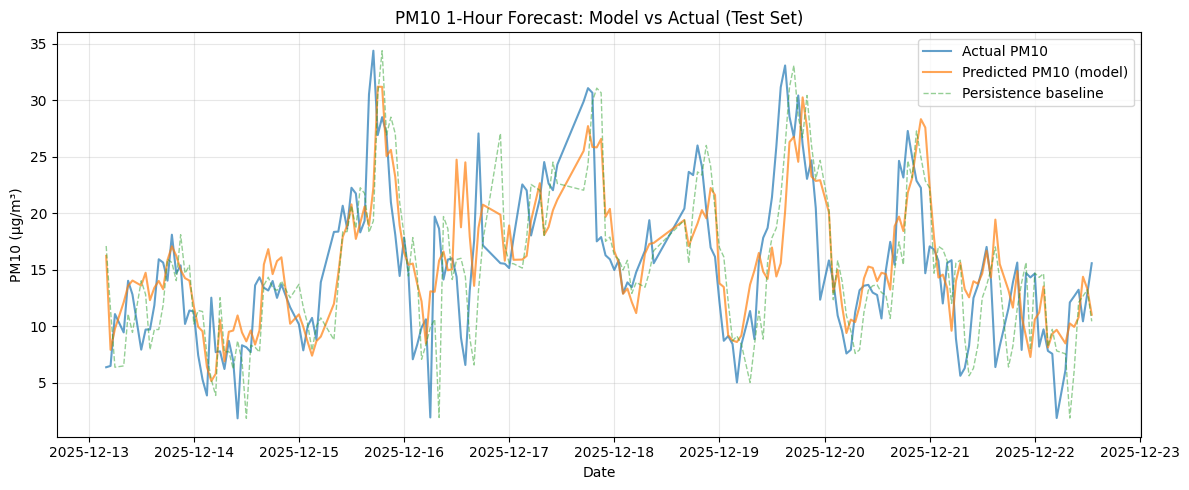

In [60]:
# Plot 1: Predictions vs Actual (test set)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates.values, y_test, label="Actual PM10", alpha=0.7, linewidth=1.5)
ax.plot(test_dates.values, y_test_pred, label="Predicted PM10 (model)", alpha=0.7, linewidth=1.5)
ax.plot(test_dates.values, persistence_pred, label="Persistence baseline", alpha=0.5, linestyle="--", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("PM10 (µg/m³)")
ax.set_title("PM10 1-Hour Forecast: Model vs Actual (Test Set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("notebooks/phase2_predictions_vs_actual.png", dpi=100)
print("✓ Saved: notebooks/phase2_predictions_vs_actual.png")
plt.show()



✓ Saved: notebooks/phase2_residuals.png


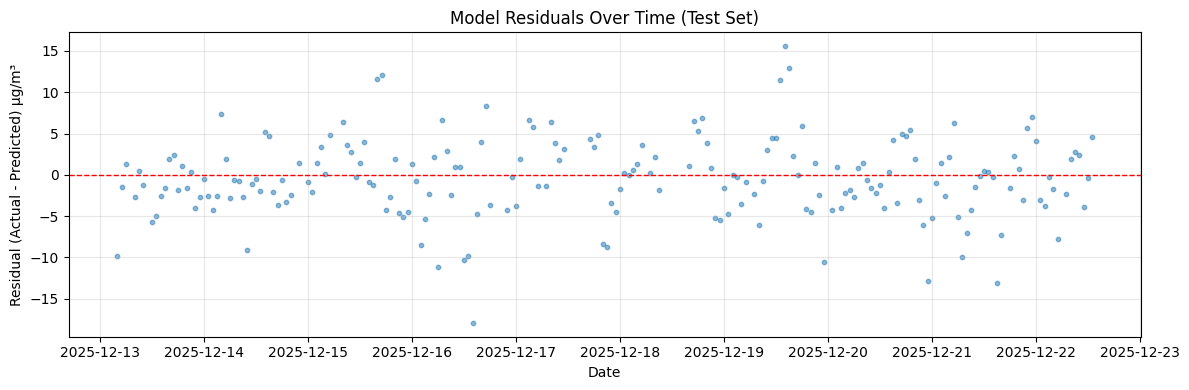

In [61]:
# Plot 2: Residuals over time
residuals = y_test - y_test_pred

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(test_dates.values, residuals, alpha=0.5, s=10)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Residual (Actual - Predicted) µg/m³")
ax.set_title("Model Residuals Over Time (Test Set)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("notebooks/phase2_residuals.png", dpi=100)
print("✓ Saved: notebooks/phase2_residuals.png")
plt.show()



✓ Saved: notebooks/phase2_scatter_pred_vs_actual.png


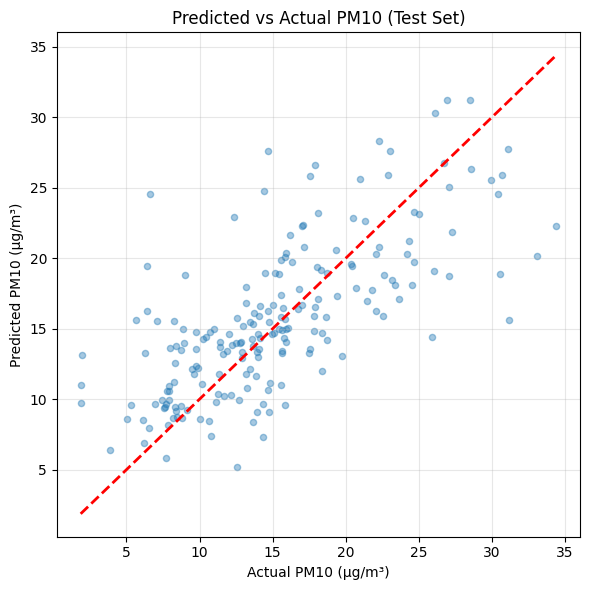

In [62]:
# Plot 3: Scatter plot (predicted vs actual)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_test_pred, alpha=0.4, s=20)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_xlabel("Actual PM10 (µg/m³)")
ax.set_ylabel("Predicted PM10 (µg/m³)")
ax.set_title("Predicted vs Actual PM10 (Test Set)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("notebooks/phase2_scatter_pred_vs_actual.png", dpi=100)
print("✓ Saved: notebooks/phase2_scatter_pred_vs_actual.png")
plt.show()



#### TASK 8: Save evaluation summary

In [63]:
summary = f"""Phase 2 Evaluation Summary
{'=' * 60}

Model: Linear Regression
Target: PM10 1-hour ahead forecast
Features: {len(feature_cols)} (time, lag, rolling, weather)

Dataset:
  Total rows: {len(df)}
  Train samples: {len(X_train)}
  Test samples: {len(X_test)}
  Date range: {df['datetime'].min()} to {df['datetime'].max()}

Test Set Performance:
  RMSE: {test_rmse:.2f} µg/m³
  MAE:  {test_mae:.2f} µg/m³
  R²:   {test_r2:.3f}

Persistence Baseline:
  RMSE: {persistence_rmse:.2f} µg/m³

Model Improvement:
  {improvement:.1f}% better than persistence baseline

Files Generated:
  - models/pm10_baseline_model.pkl
  - data/processed/chemnitz_features.csv
  - notebooks/phase2_predictions_vs_actual.png
  - notebooks/phase2_residuals.png
  - notebooks/phase2_scatter_pred_vs_actual.png
"""

with open("D:\\Projects\\aq-guardian\\aq-guardian\\docs\\phase2_results.txt", "w") as f:
    f.write(summary)

print("✓ Saved: docs/phase2_results.txt")

print("\n" + "=" * 60)
print("Phase 2 Complete!")
print("=" * 60)
print("\nNext steps:")
print("  1. Review evaluation plots in notebooks/")
print("  2. Analyze feature importance (optional)")
print("  3. Try advanced models (XGBoost, LSTM) for improvement")
print("  4. Proceed to Phase 3: Deployment or API setup")


✓ Saved: docs/phase2_results.txt

Phase 2 Complete!

Next steps:
  1. Review evaluation plots in notebooks/
  2. Analyze feature importance (optional)
  3. Try advanced models (XGBoost, LSTM) for improvement
  4. Proceed to Phase 3: Deployment or API setup
